# SC2001 Project 1 - Integration of Merge Sort & Insertion Sort


#### Prelude: Implementation of the classic Merge Sort and a modified Insertion Sort (both tracks key comparisons)


In [ ]:
def merge_sort(numArray: list[int], start: int = 0, end: int = -1) -> int:
    """
    In-place merge sort that arranges array elements in ascending order.

    Args:
        numArray: Target array to be sorted.
        start: The left bound of values for function to focus on.
        end: The right bound of values for function to focus on.

    Returns:
        The number of key comparisons made in the merge sort process.
    """
    # Initialises the start & end values, if they do not exist.
    if end == -1:
        end = len(numArray) - 1

    # Prematurely ends function if left bound exceeds right.
    if end <= start:
        return 0

    # Splits the array into 2 sections and implement merge sort on each section.
    mid = start + (end - start) // 2
    kcomp_l = merge_sort(numArray, start, mid)
    kcomp_r = merge_sort(numArray, mid + 1, end)

    # Sorts every element in the array concurrently in both sections.
    kcomp_m = merge(numArray, start, mid, end)

    return kcomp_r + kcomp_m + kcomp_l

def merge(arr: list[int], l: int, m: int, r: int) -> int:
    """
    Helper function for merge sorting.

    Args:
        arr: Array to be sorted.
        l: Left bound.
        m: Middle point.
        r: Right bound.

    Returns:
        Number of key comparisons made during sorting process.
    """
    # Initialises a sub-array with the left and right bounds, as well as pointers and
    # kcomp to track key comparisons.
    temp = arr[l:r+1]
    i, j, left_end, right_end, k = 0, m + 1 - l, m - l, r - l, l
    kcomp = 0

    # Iterates through the temp array, adding elements in ascending order to final array.
    # Overwrites array values in the original array with the next smallest element per loop.
    while i <= left_end and j <= right_end:
        kcomp += 1
        if temp[i] <= temp[j]:
            arr[k] = temp[i]
            i += 1
        else:
            arr[k] = temp[j]
            j += 1
        k += 1

    # Adds all remaining elements (if any) to the final array.
    while i <= left_end:
        arr[k] = temp[i]
        i += 1
        k += 1
    while j <= right_end:
        arr[k] = temp[j]
        j += 1
        k += 1

    return kcomp

# Test
import secrets
test_array = [secrets.randbelow(1000) for _ in range(20)]

print(f"Initial array: {test_array}")
kcomp = merge_sort(test_array)
print(f"Sorted array: {test_array}")
print(f"Key Comparisons Used: {kcomp}")

Initial array: [173, 389, 319, 831, 998, 549, 766, 379, 499, 798, 83, 547, 625, 893, 587, 187, 268, 564, 163, 789]
Sorted array: [83, 163, 173, 187, 268, 319, 379, 389, 499, 547, 549, 564, 587, 625, 766, 789, 798, 831, 893, 998]
Key Comparisons Used: 66


In [ ]:
def insertion_sort(arr: list[int], l: int = 0, r: int = -1) -> int:
    """
    Uses insertion sort to arrange array elements in ascending order.

    Args:
        arr: Number array to be sorted.
        l: Left bound of unsorted elements.
        r: Right bound of unsorted elements.

    Returns:
        Number of key comparisons made.
    """
    # Initialises end value if they do not exist and kcomp to track key comparisons.
    kcomp = 0

    if r == -1:
        r = len(arr) - 1

    # Insertion sort main function but to shift elements the function uses
    # overwriting compared to swapping.
    for i in range(l + 1, r + 1):
        j = i - 1
        tmp = arr[i]
        while j >= l:
            kcomp += 1
            if arr[j] > tmp:
                arr[j + 1] = arr[j]
                j -= 1
            else:
                break
        arr[j + 1] = tmp

    return kcomp

# Test
import secrets
test_array = [secrets.randbelow(1000) for _ in range(7)]

print(f"Initial array: {test_array}")
kcomp = insertion_sort(test_array)
print(f"Sorted array: {test_array}")
print(f"Key Comparisons Used: {kcomp}")

Initial array: [753, 780, 942, 179, 348, 793, 801]
Sorted array: [179, 348, 753, 780, 793, 801, 942]
Key Comparisons Used: 13


### (a) Algorithm implementation

##### Implement the above hybrid algorithm.

In [ ]:
def hybrid_sort(numArray: list[int], S: int, start: int = 0, end: int = -1) -> int:
    """
    Implements a hybrid sort that uses merge sort on a number array by default.
    If array size goes below S, uses insertion sort instead.
    Sorts in ascending order.

    Args:
        arr: Number array to be sorted.
        S: The threshold for deciding the switch between insertion & merge sort.
        start: The left bound of values for function to focus on.
        end: The right bound of values for function to focus on.

    Returns:
        Number of key comparisons made.
    """
    # Initialises the start & end values, if they do not exist.
    if end == -1:
        end = len(numArray) - 1

    # Prematurely ends function if left bound exceeds right.
    if end <= start:
        return 0

    # Runs an insertion sort algorithm for arrays smaller or equal to S.
    # Note that an array with start index l and end index r has r - l + 1 elements.
    # Terminates prematurely when done.
    if (end - start + 1) <= S:
        return insertion_sort(numArray, start, end)

    # Splits the array into 2 sections and implement merge sort on each section.
    mid = start + (end - start) // 2
    kcomp_l = hybrid_sort(numArray, S, start, mid)
    kcomp_r = hybrid_sort(numArray, S, mid + 1, end)

    # Sorts every element in the array concurrently in both sections.
    kcomp_m = merge(numArray, start, mid, end)

    return kcomp_r + kcomp_m + kcomp_l

# Test
import random
test_array = [random.randint(100, 1000) for _ in range(20)]

print(f"Initial array: {test_array}")
kcomp = hybrid_sort(test_array, 5)
print(f"Sorted array: {test_array}")
print(f"Key Comparisons Used: {kcomp}")

Initial array: [647, 708, 348, 504, 372, 691, 647, 677, 499, 354, 520, 370, 348, 989, 129, 953, 603, 323, 392, 156]
Sorted array: [129, 156, 323, 348, 348, 354, 370, 372, 392, 499, 504, 520, 603, 647, 647, 677, 691, 708, 953, 989]
Key Comparisons Used: 74


### (b) Generate input data

##### Generate arrays of increasing sizes, in a range from 1,000 to 10 million. For each of the sizes, generate a random dataset of integers in the range of [1, …, x], where x is the largest number you allow for your datasets.

In [ ]:
# Already done in C++ and exported out to .csv files for analysis in (c) and (d)

""" import random
input_sizes = [j * 10 ** i for i in range(3, 7) for j in range(1, 10)] + [10000000]
MAX_INPUT = 10 ** 8 + 5
INPUTS = []
for s in input_sizes:
    arr = [random.randint(1, MAX_INPUT) for _ in range(s)]
    INPUTS.append(arr)

# Test
print(INPUTS[0])
INPUTS[1] """

' import random\ninput_sizes = [j * 10 ** i for i in range(3, 7) for j in range(1, 10)] + [10000000]\nMAX_INPUT = 10 ** 8 + 5\nINPUTS = []\nfor s in input_sizes:\n    arr = [random.randint(1, MAX_INPUT) for _ in range(s)]\n    INPUTS.append(arr)\n\n# Test\nprint(INPUTS[0])\nINPUTS[1] '

### (c) Analyse time complexity

##### i. With the value of S **fixed**, plot the number of key comparisons over different sizes of the input list n. Compare your empirical results with your theoretical analysis of the time complexity.

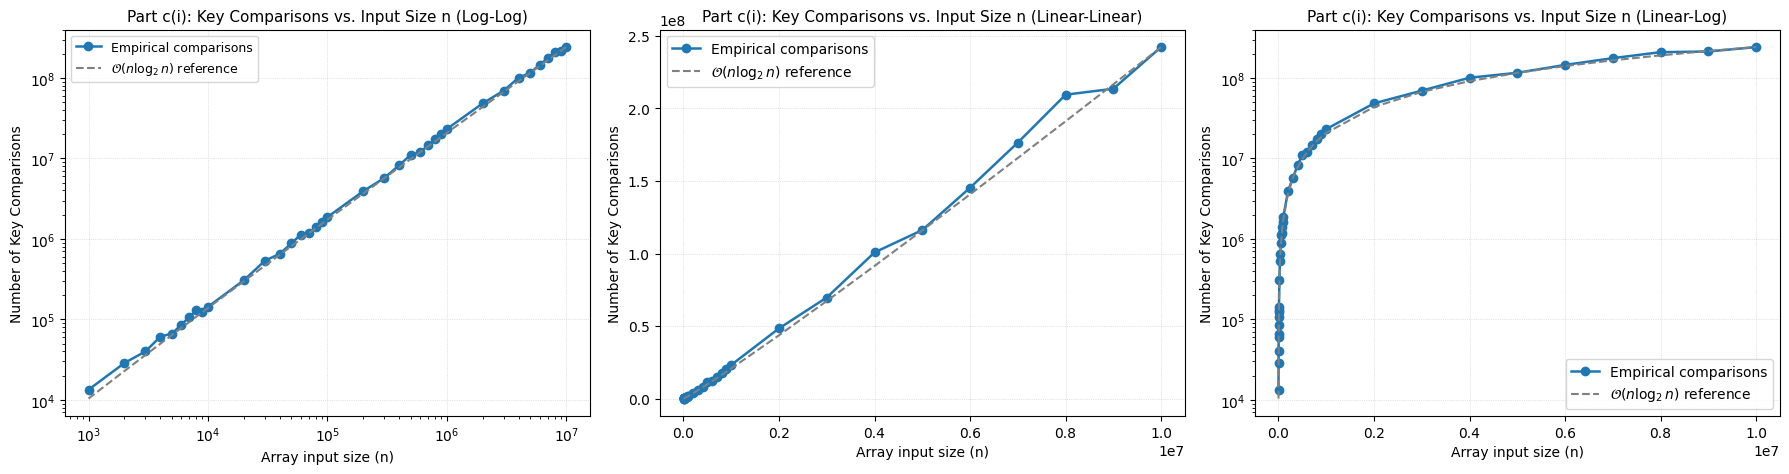

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load data
df_fixed_S_vary_n = pd.read_csv("data/results/fixed_S_vary_n.csv")
S = df_fixed_S_vary_n["S"][0]

xpoints = df_fixed_S_vary_n["n"]
ypoints = df_fixed_S_vary_n["key_comparisons"]

# Calculate and plot theoretical O(n log n) reference curve
n_vals = df_fixed_S_vary_n["n"].to_numpy()
theoretical = n_vals * np.log2(n_vals)
theoretical *= df_fixed_S_vary_n["key_comparisons"].iloc[-1] / theoretical[-1]

# Create figure and axis objects
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))


# ----------------- Plot 1: Log - Log Scale -----------------
ax1.plot(xpoints, ypoints, marker="o", linestyle="-", linewidth=1.8, label="Empirical comparisons")
ax1.plot(n_vals, theoretical, linestyle="--", linewidth=1.5, color="gray", label=r"$\mathcal{O}(n \log_2 n)$ reference")
# Axis scale and labels
ax1.set_title(f'Part c(i): Key Comparisons vs. Input Size n (Log-Log)', fontsize=11)
ax1.set_xlabel("Array input size (n)", fontsize=10)
ax1.set_xscale("log")
ax1.set_ylabel("Number of Key Comparisons", fontsize=10)
ax1.set_yscale("log")
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, linestyle=":", linewidth=0.5, alpha=0.7)


# ----------------- Plot 2: Linear - Linear Scale -----------------
ax2.plot(xpoints, ypoints, marker="o", linestyle="-", linewidth=1.8, label="Empirical comparisons")
ax2.plot(n_vals, theoretical, linestyle="--", linewidth=1.5, color="gray", label=r"$\mathcal{O}(n \log_2 n)$ reference")

ax2.set_title(f'Part c(i): Key Comparisons vs. Input Size n (Linear-Linear)', fontsize=11)
ax2.set_xlabel('Array input size (n)', fontsize=10)
ax2.set_ylabel('Number of Key Comparisons', fontsize=10)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, linestyle=":", linewidth=0.5, alpha=0.7)
ax2.legend()


# ----------------- Plot 3: Linear - Log Scale -----------------
ax3.plot(xpoints, ypoints, marker="o", linestyle="-", linewidth=1.8, label="Empirical comparisons")
ax3.plot(n_vals, theoretical, linestyle="--", linewidth=1.5, color="gray", label=r"$\mathcal{O}(n \log_2 n)$ reference")

ax3.set_title(f'Part c(i): Key Comparisons vs. Input Size n (Linear-Log)', fontsize=11)
ax3.set_xlabel('Array input size (n)', fontsize=10)
ax3.set_ylabel('Number of Key Comparisons', fontsize=10)
ax3.set_yscale('log')  # <--- Displays smaller n sizes across orders of magnitude
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, linestyle=":", linewidth=0.5, alpha=0.7)
ax3.legend()


plt.tight_layout()
plt.show()

##### ii. With the input size n **fixed**, plot the number of key comparisons over different values of S. Compare your empirical results with your theoretical analysis of the time complexity.


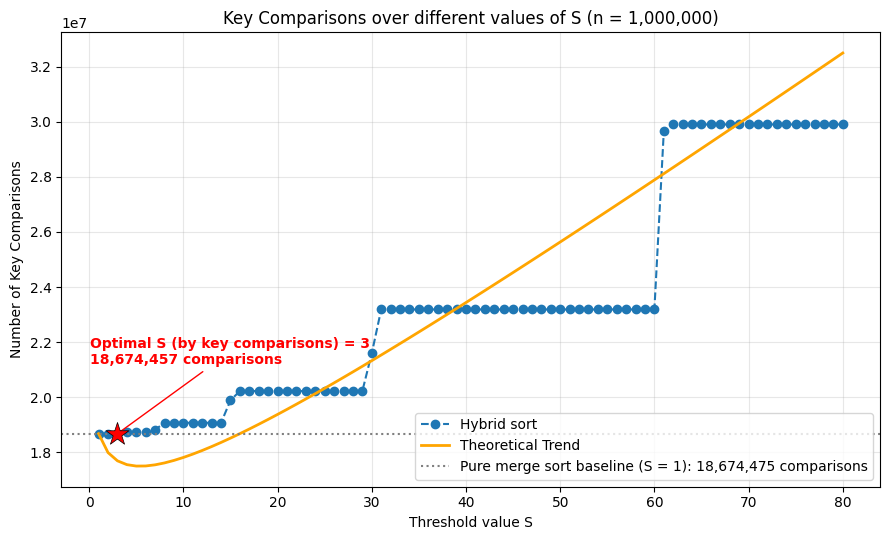


Optimal S by key comparisons: S = 3 (18,674,457 vs 18,674,475 comparisons for pure merge sort, a 0.00% reduction)


In [ ]:
# We will only measure this function: KeyComp(S) with discrete points before plotting

# To do that, we shall measure a table with a fixed SampleArr and S. S should run from 1 to 80.
# Reason to peg S from 1 to 80:
# Hybrid Sort's base cases use Insertion Sort which has an worst case asymptotic runtime of W(S) = S(S-1)/2
# Merge Sort's when subarray sizes are <= to S which has an asymptotic runtime of W(S) = S * log(S) + S

# So actually, key comparisons of the hybrid algorithm is not asymptotically lower the normal merge sort for huge S,
# and the 2 W(S) roughly intersect at S = 4.
# The difference between the two methods is at the execution time, which merge sort is worse because of overhead
# recursive calls compared to hybrid sort.

# Because of the reasons above, we still test for S up to 80.

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

n = 1_000_000
df_fixed_n_vary_S_1000000 = pd.read_csv("data/results/fixed_n_vary_S_1000000.csv")

S_vals = df_fixed_n_vary_S_1000000["S"]
kcomp_vals = df_fixed_n_vary_S_1000000["key_comparisons"]

# Optimal S by key comparisons: the S with the fewest key comparisons
best_idx = kcomp_vals.idxmin()
best_S = int(S_vals[best_idx])
best_kcomp = int(kcomp_vals[best_idx])
baseline_kcomp = int(kcomp_vals.iloc[0])  # pure merge sort (S = 1)

# Theoretical analysis
c_merge = kcomp_vals[0] / (n * np.log2(n))
c_insert = 0.25

theory_merge = c_merge * n * np.log2(n / S_vals)
theory_insert = c_insert * n * (S_vals - 1)
theory_curve = theory_merge + theory_insert

plt.figure(figsize=(9, 5.5))
plt.plot(S_vals, kcomp_vals, marker='o', linestyle='--', color='tab:blue', label='Hybrid sort')
plt.plot(S_vals, theory_curve, color='orange', linestyle='-', linewidth=2, label='Theoretical Trend')
plt.axhline(baseline_kcomp, color='gray', linestyle=':', linewidth=1.5,
            label=f'Pure merge sort baseline (S = 1): {baseline_kcomp:,} comparisons')
plt.annotate(f'Optimal S (by key comparisons) = {best_S}\n{best_kcomp:,} comparisons',
             xy=(best_S, best_kcomp), xytext=(-20, 50), textcoords='offset points',
             fontsize=10, fontweight='bold', color='red',
             arrowprops=dict(arrowstyle='-', color='red'))
plt.scatter([best_S], [best_kcomp], color='red', marker='*', s=300, zorder=5,
            edgecolor='black', linewidth=0.5)

plt.xlabel('Threshold value S')
plt.ylabel('Number of Key Comparisons')
plt.title(f'Key Comparisons over different values of S (n = {n:,})')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pct = 1 - best_kcomp / baseline_kcomp
print()
print(f'Optimal S by key comparisons: S = {best_S} '
      f'({best_kcomp:,} vs {baseline_kcomp:,} comparisons for pure merge sort, '
      f'a {pct:.2%} reduction)')


##### iii. Using different sizes of input datasets, study how to determine an optimal value of S for the best performance of this hybrid algorithm.

**Methodology.** Key comparisons alone cannot justify the hybrid algorithm: for large `S` the hybrid can even make *more* key comparisons than pure merge sort. The real benefit lies in **CPU runtime**, because insertion sort avoids the recursive-call and sub-array-copy overhead of merge sort on small sub-arrays.

Therefore, for part (c)(iii) we measure the **runtime** of the C++ hybrid sort with a **fixed `n`** while varying `S` from 1 to 80, for input sizes `n` = 1,000 up to 10,000,000. Each point is a single measured run, so timings for small `n` are noisy; a light rolling-median trend line is overlaid so the true optimum is visible (individual noisy spikes above a ratio of 1.6 are clipped in the left panel). The **optimal `S*`** for each `n` is the value of `S` with the fastest measured runtime, marked with a star.


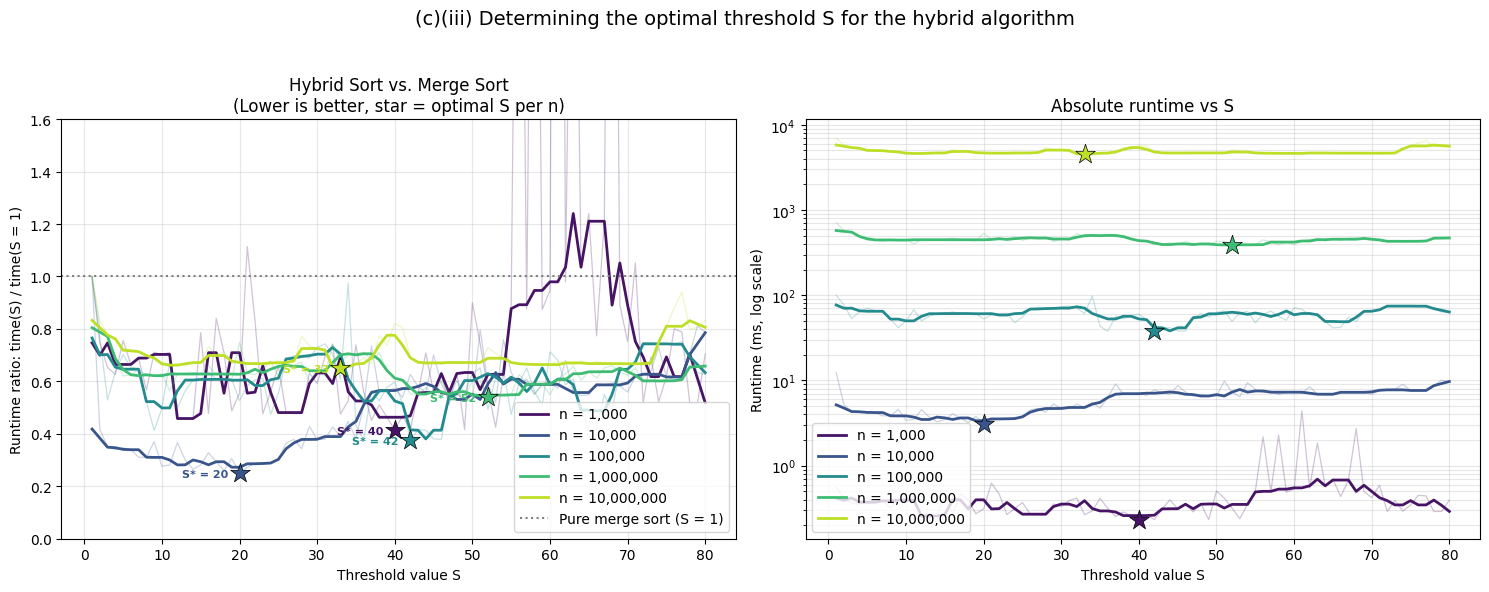

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Runtime of the hybrid sort with fixed n, varying S from 1 to 80 (measured in C++)
n_values = [1000, 10000, 100000, 1000000, 10000000]
df_by_n = {n: pd.read_csv(f"data/results/fixed_n_vary_S_{n}.csv").sort_values("S")
           for n in n_values}

colors = plt.cm.viridis(np.linspace(0.05, 0.9, len(n_values)))
window = 5  # rolling-median window to smooth single-run timing noise

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

optimal_rows = []
for color, n in zip(colors, n_values):
    df = df_by_n[n]
    S = df["S"].to_numpy(dtype=float)
    ratio = df["ratio_with_S=1"].to_numpy(dtype=float)
    time_ms = df["time_ms"].to_numpy(dtype=float)

    ratio_trend = pd.Series(ratio).rolling(window, center=True, min_periods=1).median()
    time_trend = pd.Series(time_ms).rolling(window, center=True, min_periods=1).median()

    # Optimal S = the S with the fastest measured runtime for this n
    best_i = int(np.argmin(time_ms))

    # ---- Left panel: runtime relative to pure merge sort (S = 1) ----
    ax1.plot(S, ratio, color=color, alpha=0.25, linewidth=0.9)
    ax1.plot(S, ratio_trend, color=color, linewidth=2.0, label=f'n = {n:,}')
    ax1.scatter(S[best_i], ratio[best_i], color=color, marker='*', s=220,
                zorder=5, edgecolor='black', linewidth=0.5) # Here is where the star in the plot comes from
    ax1.annotate(f'S* = {S[best_i]:.0f}', (S[best_i], ratio[best_i]),
                 textcoords='offset points', xytext=(-25, -3), ha='center',
                 fontsize=8, fontweight='bold', color=color)

    # ---- Right panel: absolute runtime (log scale) ----
    ax2.plot(S, time_ms, color=color, alpha=0.25, linewidth=0.9)
    ax2.plot(S, time_trend, color=color, linewidth=2.0, label=f'n = {n:,}')
    ax2.scatter(S[best_i], time_ms[best_i], color=color, marker='*', s=220,
                zorder=5, edgecolor='black', linewidth=0.5) # Here is where the star in the plot comes from

    optimal_rows.append({'n': n, 'optimal_S': int(S[best_i]),
                         'best_time_ms': time_ms[best_i],
                         'time_at_S=1_ms': time_ms[0],
                         'speedup': time_ms[0] / time_ms[best_i]})

# Reference: parity with pure merge sort (S = 1)
ax1.axhline(1.0, color='gray', linestyle=':', linewidth=1.5,
            label='Pure merge sort (S = 1)')

# Labels & Scales
ax1.set_xlabel('Threshold value S')
ax1.set_ylabel('Runtime ratio: time(S) / time(S = 1)')
ax1.set_title('Hybrid Sort vs. Merge Sort\n(Lower is better, star = optimal S per n)')
ax1.set_ylim(0, 1.6)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

ax2.set_yscale('log')
ax2.set_xlabel('Threshold value S')
ax2.set_ylabel('Runtime (ms, log scale)')
ax2.set_title('Absolute runtime vs S')
ax2.legend(loc='lower left')
ax2.grid(True, which='both', alpha=0.3)

fig.suptitle('(c)(iii) Determining the optimal threshold S for the hybrid algorithm', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Optimal threshold S* (fastest measured runtime) for each input size n:
 Input size n  Optimal S*  Best runtime (ms)  Runtime at S=1 (ms)  Speedup vs S=1
         1000          40              0.232                0.560            2.41
        10000          20              3.093               12.363            4.00
       100000          42             37.687              100.261            2.66
      1000000          52            386.108              713.148            1.85
     10000000          33           4532.390             6958.810            1.54


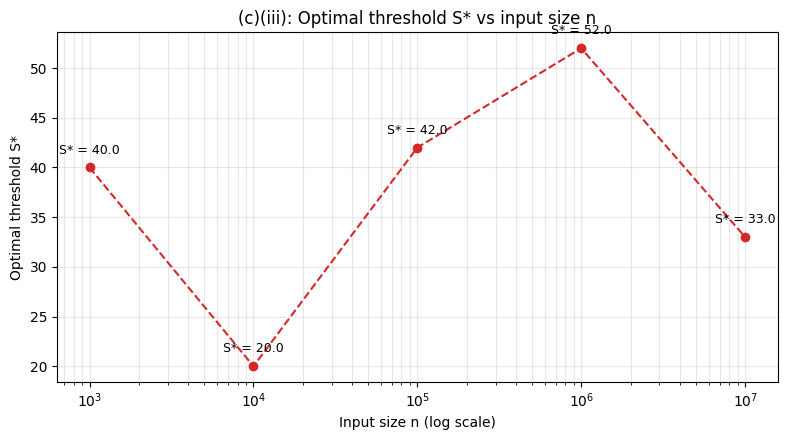

In [ ]:
# Summary: optimal S for each input size, and how S* scales with n
optimal_df = pd.DataFrame(optimal_rows).sort_values('n').reset_index(drop=True)
optimal_df['best_time_ms'] = optimal_df['best_time_ms'].round(3)
optimal_df['time_at_S=1_ms'] = optimal_df['time_at_S=1_ms'].round(3)
optimal_df['speedup'] = optimal_df['speedup'].round(2)
optimal_df = optimal_df.rename(columns={
    'n': 'Input size n',
    'optimal_S': 'Optimal S*',
    'best_time_ms': 'Best runtime (ms)',
    'time_at_S=1_ms': 'Runtime at S=1 (ms)',
    'speedup': 'Speedup vs S=1',
})
print('Optimal threshold S* (fastest measured runtime) for each input size n:')
print(optimal_df.to_string(index=False))

plt.figure(figsize=(8, 4.5))
plt.plot(optimal_df['Input size n'], optimal_df['Optimal S*'],
         marker='o', linestyle='--', color='tab:red')
for _, row in optimal_df.iterrows():
    plt.annotate(f"S* = {row['Optimal S*']}",
                 (row['Input size n'], row['Optimal S*']),
                 textcoords='offset points', xytext=(0, 10), ha='center',
                 fontsize=9)
plt.xscale('log')
plt.xlabel('Input size n (log scale)')
plt.ylabel('Optimal threshold S*')
plt.title('(c)(iii): Optimal threshold S* vs input size n')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


**Results.** The optimal threshold `S*` is not a single magic number — it depends on the input size, but consistently lands in the range **S ≈ 20–50**:

| Input size n | Optimal S* | Best runtime | Runtime at S=1 (merge sort) | Speedup |
|---|---|---|---|---|
| 1,000 | 40 | 0.232 ms | 0.560 ms | ~2.4× |
| 10,000 | 20 | 3.09 ms | 12.36 ms | ~4.0× |
| 100,000 | 42 | 37.69 ms | 100.26 ms | ~2.7× |
| 1,000,000 | 52 | 386.11 ms | 713.15 ms | ~1.8× |
| 10,000,000 | 33 | 4,532.39 ms | 6,958.81 ms | ~1.5× |

Observations:

- For **every** input size, the hybrid sort is faster than pure merge sort — all curves sit below the ratio = 1.0 baseline, with speedups of ~1.5–4×.
- The optimal `S*` stays within **~20–50** for all sizes tested, so a single practical choice of **S = 32** performs close to optimal across the board. This is why `S = 32` was used for the fixed-S experiments in (c)(i) and (d).
- By key comparisons alone (part (c)(ii)), the optimum is far smaller (S ≈ 3–4). This confirms that **runtime, not comparison count**, is the right metric for choosing S — the hybrid wins by avoiding recursion/copy overhead, not by comparing fewer keys.


### (d) Compare with original Merge Sort:

##### Implement the original version of merge sort (as learnt in lecture). Compare its performance against the above hybrid algorithm in terms of the number of key comparisons and CPU times on the dataset with 10 million integers. You can use the optimal value of S obtained in (c) for this task.

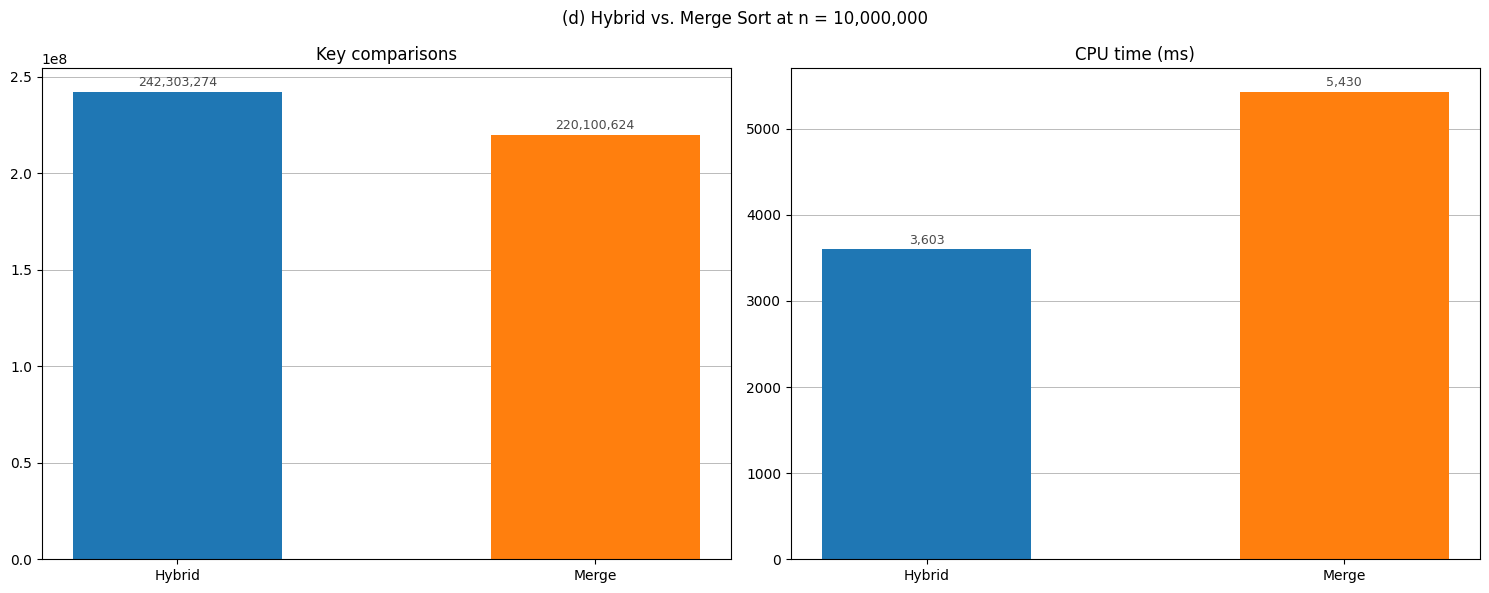

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df_10_mil_comp = pd.read_csv("data/results/10_mil_comp.csv")

INK_SECONDARY = "#4a4a4a"

# Figure setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
axes = [ax1, ax2]

metrics = [("key_comparisons", "Key comparisons"), ("time_ms", "CPU time (ms)")]

for ax, (col, label) in zip(axes, metrics):
    bars = ax.bar(
        df_10_mil_comp["algorithm"],
        df_10_mil_comp[col],
        color=["#1f77b4", "#ff7f0e"],  # 2 distinct colors
        width=0.5,
    )
    ax.set_title(label)
    ax.grid(True, axis="y", linewidth=0.6)
    ax.set_axisbelow(True)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:,.0f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            color=INK_SECONDARY,
        )

fig.suptitle("(d) Hybrid vs. Merge Sort at n = 10,000,000")
fig.tight_layout()
plt.show()

In the plots, Key Comparisons of both algorithms are the same, but the CPU time of Merge Sort is 50% longer than Hybrid Sort - consistent with results we found at part (c) iii where optimal S is 33, which is only 1 away from 32.